ใน PSO เรามี:

* Particle = คำตอบหนึ่งตัว

* Position x

* Velocity v

* pbest = ค่าที่ดีที่สุดของตัวเอง

* gbest = ค่าที่ดีที่สุดของทั้งฝูง

In [ ]:
import numpy as np

In [ ]:
#first step we choose find a Objecttive Function
def fitness(x):
  return np.sum(x**2, axis=1)

In [ ]:
num_particle = 10 # จำนวน particle
max_iter = 300 # จำนวนรอบ
w = 0.5 # inertia weigt ความเฉื่อย (กันไม่ให้แกว่งแรงเกิน)
c1 = 1.5 # cognitive (pbest) ชื่อประสบการณ์ตัวเอง
c2 = 1.5 # social (gbest) เชื่อฝูง
dim = 10

In [ ]:
#position ของ particle
x= np.random.uniform(-10, 10, (num_particle,dim))
#velocity เริ่มต้น
y= np.random.uniform(-1, 1, num_particle)

In [ ]:
# setting your pbest and gbest

pbest_value = fitness(pbest)

gbest_index = np.argmin(pbest_value)
gbest = pbest[gbest_index]
gbest_value = pbest_value[gbest_index]


In [ ]:
best_fitness_history = []

for iteration in range(max_iter):

    r1 = np.random.rand(num_particle, dim)
    r2 = np.random.rand(num_particle, dim)

    # Update velocity
    v = (w * v
         + c1 * r1 * (pbest - x)
         + c2 * r2 * (gbest - x))

    # 🔑 Update position
    x = x + v

    # ✅ ใส่ clip ตรงนี้
    x = np.clip(x, -10, 10)

    # Evaluate fitness
    current_value = fitness(x)

    # Update pbest
    better_mask = current_value < pbest_value
    pbest[better_mask] = x[better_mask]
    pbest_value[better_mask] = current_value[better_mask]

    # Update gbest
    min_index = np.argmin(pbest_value)
    if pbest_value[min_index] < gbest_value:
        gbest = pbest[min_index]
        gbest_value = pbest_value[min_index]
    best_fitness_history.append(gbest_value)

    print(f"Iter {iteration+1:02d} | Best fitness = {gbest_value:.5f}")


Iter 01 | Best fitness = 0.00000
Iter 02 | Best fitness = 0.00000
Iter 03 | Best fitness = 0.00000
Iter 04 | Best fitness = 0.00000
Iter 05 | Best fitness = 0.00000
Iter 06 | Best fitness = 0.00000
Iter 07 | Best fitness = 0.00000
Iter 08 | Best fitness = 0.00000
Iter 09 | Best fitness = 0.00000
Iter 10 | Best fitness = 0.00000
Iter 11 | Best fitness = 0.00000
Iter 12 | Best fitness = 0.00000
Iter 13 | Best fitness = 0.00000
Iter 14 | Best fitness = 0.00000
Iter 15 | Best fitness = 0.00000
Iter 16 | Best fitness = 0.00000
Iter 17 | Best fitness = 0.00000
Iter 18 | Best fitness = 0.00000
Iter 19 | Best fitness = 0.00000
Iter 20 | Best fitness = 0.00000
Iter 21 | Best fitness = 0.00000
Iter 22 | Best fitness = 0.00000
Iter 23 | Best fitness = 0.00000
Iter 24 | Best fitness = 0.00000
Iter 25 | Best fitness = 0.00000
Iter 26 | Best fitness = 0.00000
Iter 27 | Best fitness = 0.00000
Iter 28 | Best fitness = 0.00000
Iter 29 | Best fitness = 0.00000
Iter 30 | Best fitness = 0.00000
Iter 31 | 

In [ ]:
print("\nBest solution found:")
print("x =", np.array2string(gbest, precision=5))
print("f(x) =", gbest_value)



Best solution found:
x = [ 5.82457e-09  3.12895e-08 -2.99282e-08 -2.15683e-07 -7.54853e-08
  2.40769e-07 -1.83040e-08 -1.33953e-07 -3.22399e-09  4.01355e-07]
f(x) = 2.914700802239403e-13


### plot graph for show everything

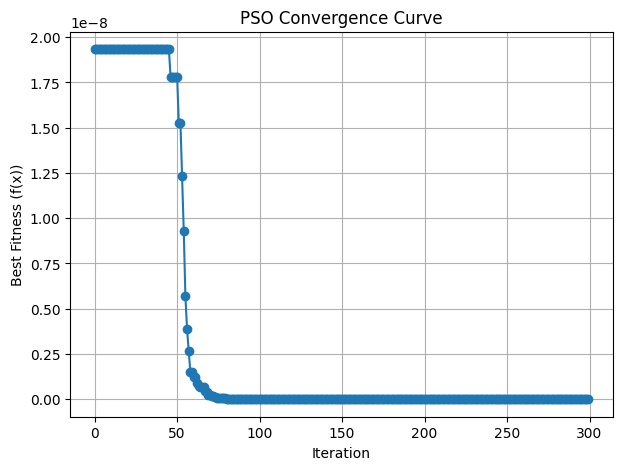

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(best_fitness_history, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Best Fitness (f(x))")
plt.title("PSO Convergence Curve")
plt.grid(True)
plt.show()


### plot graph with active:hover point


In [ ]:
import plotly.express as px
import pandas as pd

In [ ]:
df = pd.DataFrame({
    "Iteration": range(1, len(best_fitness_history) + 1),
    "Best Fitness": best_fitness_history
})


In [ ]:
fig = px.line(
    df,
    x="Iteration",
    y="Best Fitness",
    title="PSO Convergence Curve (Interactive)",
    markers=True
)

fig.update_layout(
    xaxis_title="Iteration",
    yaxis_title="Best Fitness",
    hovermode="x unified"
)

fig.show()


In [ ]:
fig.update_yaxes(type="log")
fig.show()
